# blue line analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np
from pprint import pprint
import pickle
import heapq
from collections import deque
from tqdm import tqdm
from sklearn.cross_decomposition import PLSRegression

In [2]:
# import dataframe

station = pd.read_csv(r'..\data\blue_station_stat.csv')
timetable = pd.read_csv(r'..\data\blue_timetable.csv')
headway = pd.read_csv(r'..\data\blue_headway.csv')

## plot average headway for each train over 100 sims

In [3]:
headway

,train_id,headway,rep
0,0,43,1
1,0,118,1
2,0,228,1
3,0,319,1
4,0,418,1
...,...,...,...
401366,5,242,100
401367,5,248,100
401368,5,264,100
401369,5,267,100


In [4]:
headway['stop'] = 1
headway['stop'] = headway.groupby(['train_id', 'rep'])['stop'].cumsum()

In [5]:
def plot_headway(headway, n_stops):
    ntrains = len(headway['train_id'].unique())
    fig, axes = plt.subplots(nrows=ntrains, figsize=(20, 20))
    n_stops = n_stops

    for i in range(ntrains):
        train_id = i
        temp = headway[headway['train_id']==train_id]
        temp = temp.groupby(['train_id', 'stop']).agg({'headway': ['mean', 'std']}).round(3)
        temp['ub'] = temp[('headway', 'mean')] + temp[('headway', 'std')]
        temp['lb'] = temp[('headway', 'mean')] - temp[('headway', 'std')]


        temp = temp.iloc[:n_stops]

        stops = np.arange(1, n_stops+1)

        label_mean   = 'Mean headway' if i == 0 else '_nolegend_'
        label_target = 'Target'       if i == 0 else '_nolegend_'
        label_band   = '±1 std'       if i == 0 else '_nolegend_'


        axes[i].plot(temp[('headway', 'mean')].values, label=label_mean)
        axes[i].axhline(y=2400/ntrains, color='red', linestyle='--', linewidth=1, label=label_target)
        axes[i].fill_between(stops, temp['ub'], temp['lb'], alpha=0.3, label=label_band)
        axes[i].set_ylabel(f'train_id: {train_id}')
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), ncol=3)
    fig.supxlabel('Stop number')
    fig.supylabel('Headway (seconds)')

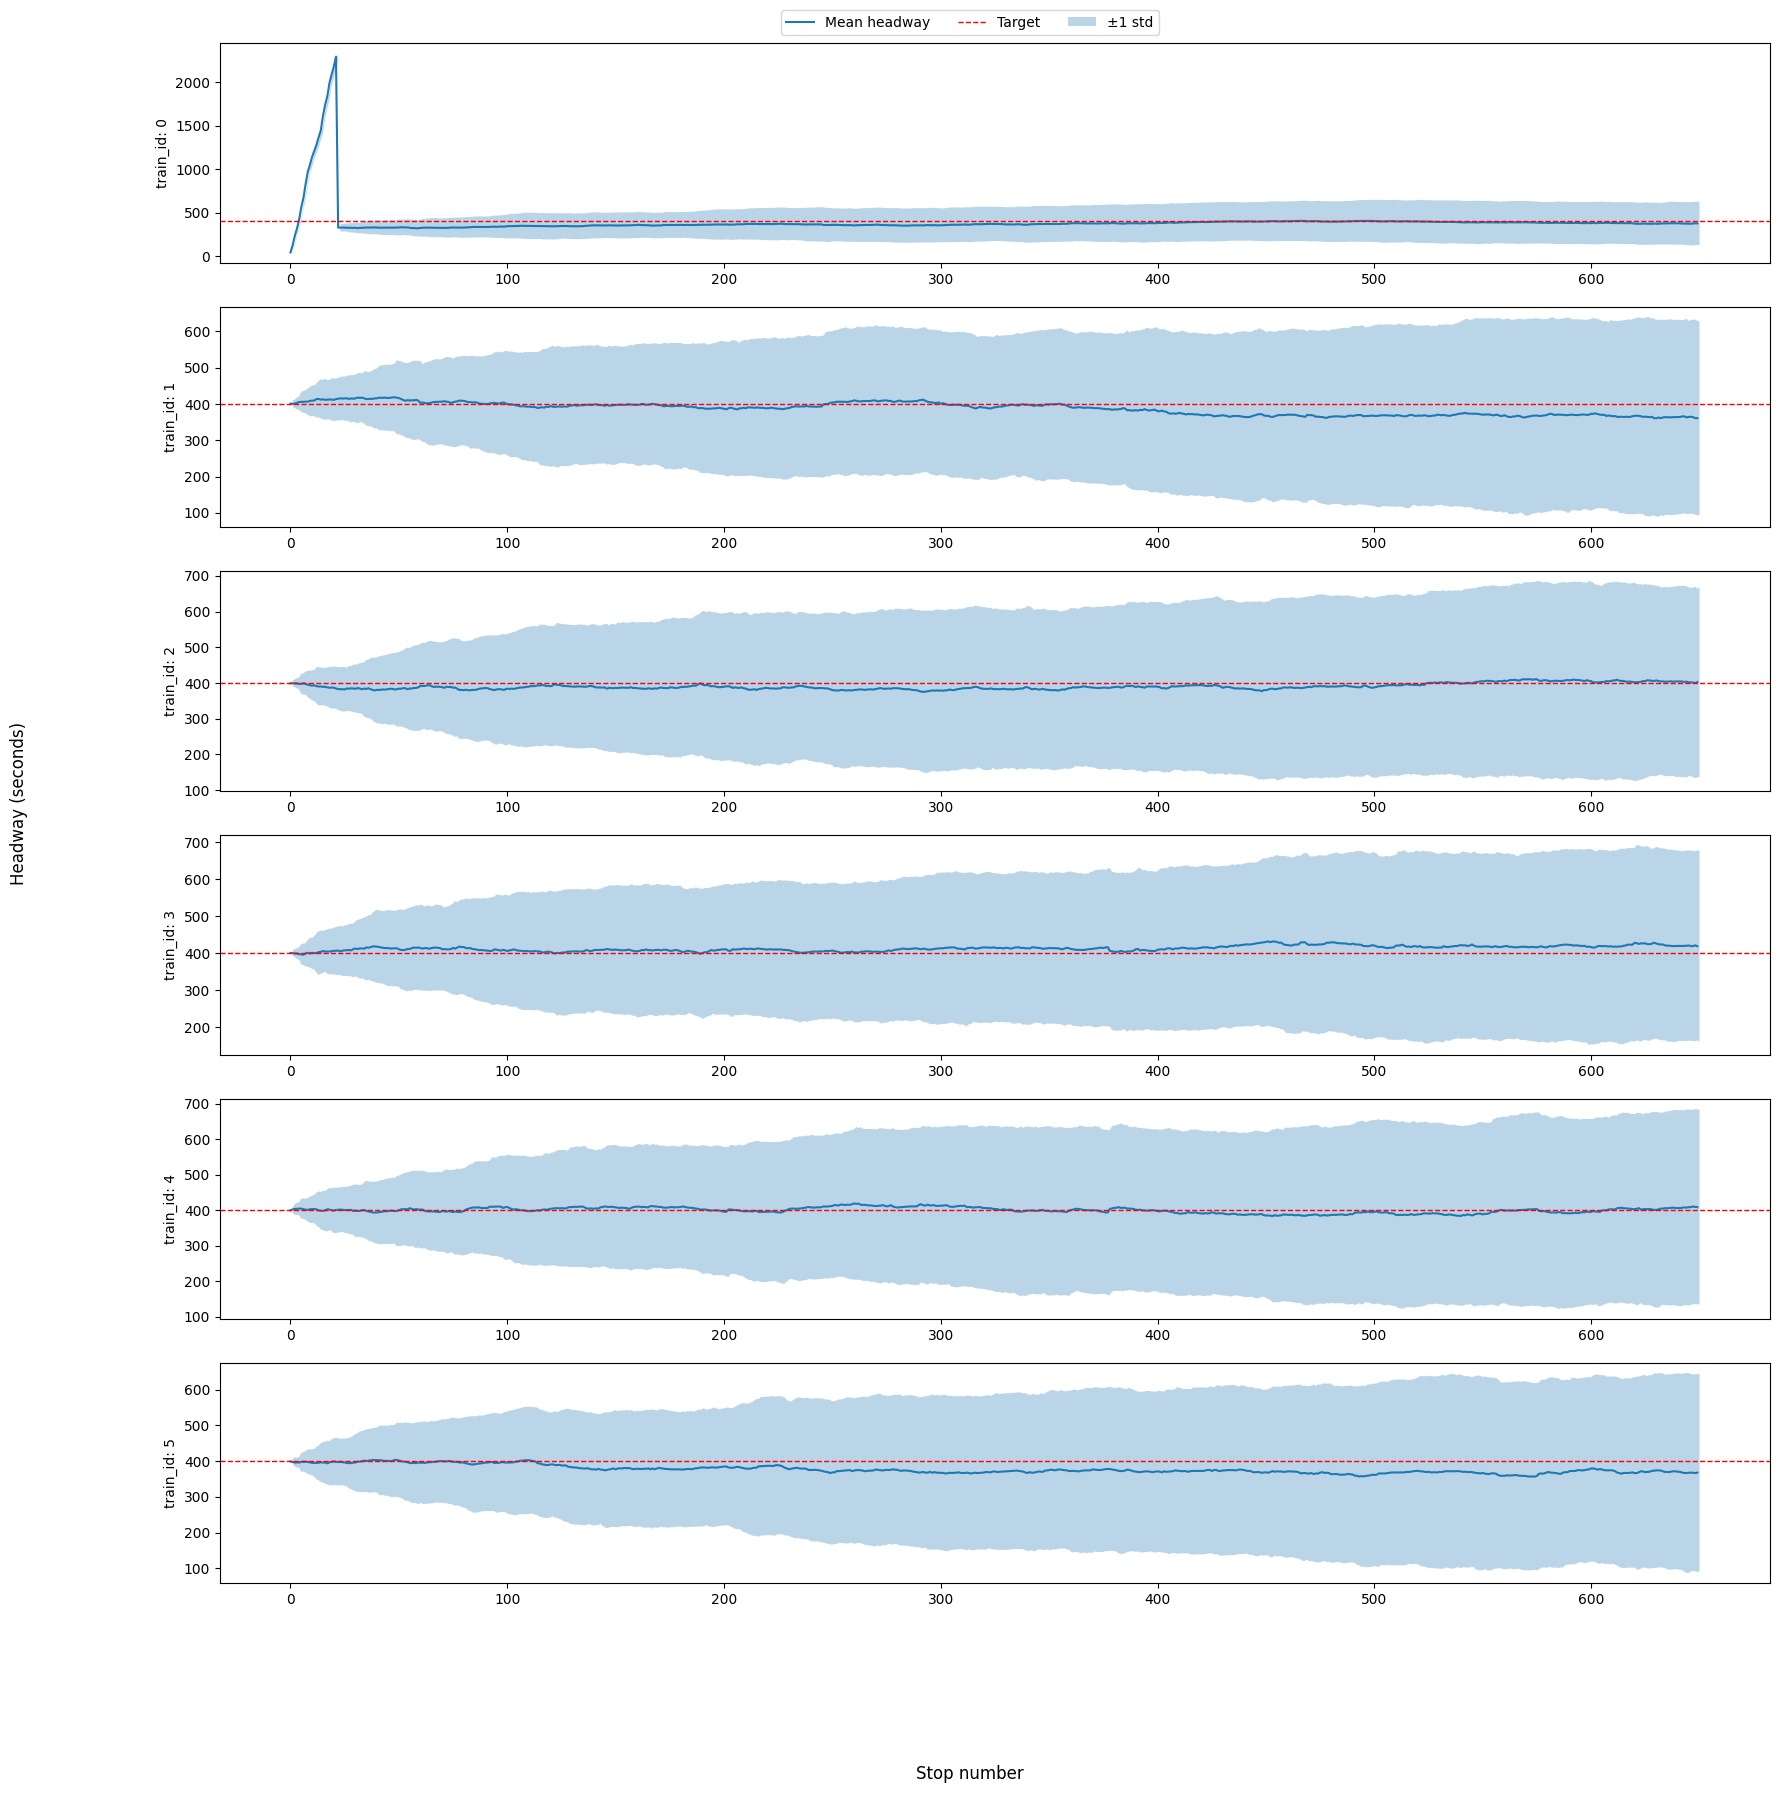

In [6]:
plot_headway(headway, 650)

## partial regression

In [7]:
headway['headway_rel'] = headway['headway'] - (2400/len(headway['train_id'].unique())) 
headway_pivot = headway.pivot_table(index=['rep', 'stop'], columns='train_id', values='headway_rel',).reset_index()
headway_pivot.drop(columns='rep', inplace=True)
headway_pivot.dropna(inplace=True)
headway_pivot

train_id,stop,0,1,2,3,4,5
0,1,-357.0,5.0,1.0,-7.0,5.0,-11.0
1,2,-282.0,0.0,15.0,-10.0,16.0,-22.0
2,3,-172.0,-8.0,18.0,-13.0,24.0,-29.0
3,4,-81.0,-8.0,12.0,-4.0,21.0,-39.0
4,5,18.0,-9.0,41.0,1.0,-19.0,-33.0
...,...,...,...,...,...,...,...
67772,656,156.0,261.0,-244.0,-227.0,139.0,-158.0
67773,657,160.0,252.0,-260.0,-214.0,139.0,-152.0
67774,658,158.0,241.0,-234.0,-216.0,131.0,-136.0
67775,659,175.0,223.0,-227.0,-211.0,134.0,-133.0


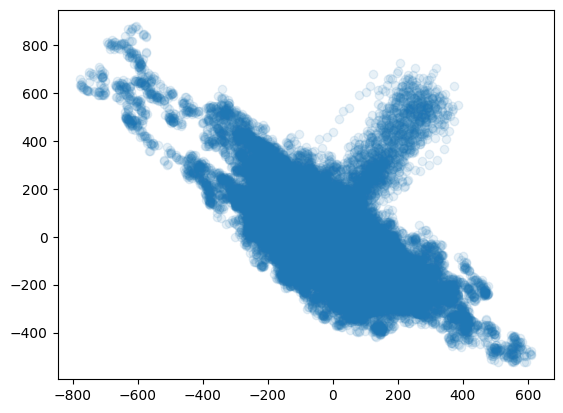

In [99]:
from sklearn.linear_model import LinearRegression

confound = headway['train_id'].unique().tolist()
pred = 3
confound.remove(pred)

target = 1 #confound[0]
confound.remove(target)



target_model = LinearRegression().fit(headway_pivot[confound], headway_pivot[target])
pred_model = LinearRegression().fit(headway_pivot[confound], headway_pivot[pred])

target_resd = headway_pivot[target]-target_model.predict(headway_pivot[confound])
pred_resd = headway_pivot[pred]-pred_model.predict(headway_pivot[confound])

plt.scatter(pred_resd.values, target_resd.values, alpha=0.1)

# regression using partial correlation

(1.144, 20.03)
(-0.921, -1.012)


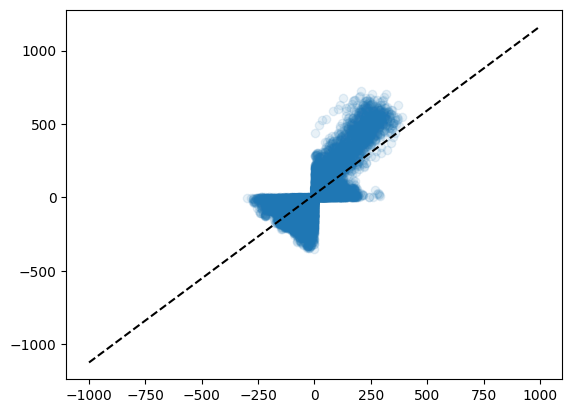

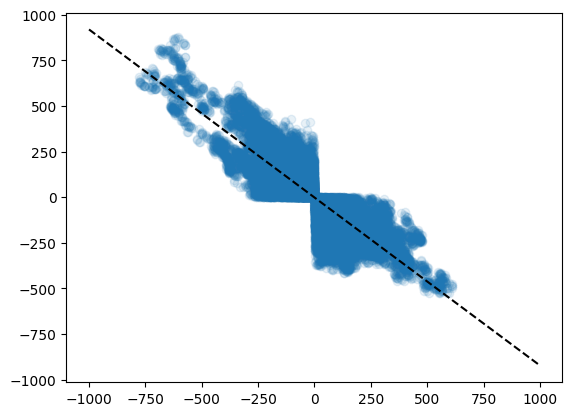

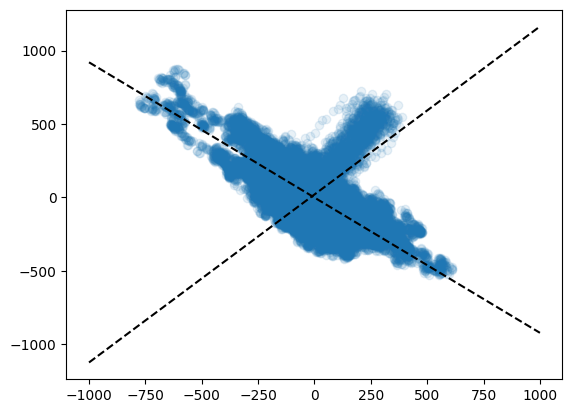

In [100]:
from sklearn.linear_model import LinearRegression
import numpy as np

resd = pd.DataFrame({'pred_resd': pred_resd.values,
                  'target_resd': target_resd.values})

pred = resd['pred_resd']-resd['pred_resd'].mean()
target = resd['target_resd']-resd['target_resd'].mean()
resd['cor'] = ((pred*target)/(np.sqrt((pred**2)*(target**2)))).round(2)

m_lst = []
c_lst = []


for cor in [1,-1]:
    data = resd[resd['cor']==cor]
    x = data['pred_resd'].to_numpy().reshape(-1,1)
    y = data['target_resd'].to_numpy()

    model = LinearRegression()
    model.fit(x,y)
        

    m = round(model.coef_[0].item(), 3)
    c = round(model.intercept_.item(), 3)

    m_lst.append(m)
    c_lst.append(c)

    print((m, c))
    xaxis = np.linspace(-1000, 1000, 3)
    yaxis = m*xaxis + c
    plt.figure()
    plt.plot(xaxis, yaxis, 'k--')
    plt.scatter(x, y, alpha=0.1)


plt.figure()
plt.scatter(resd['pred_resd'],resd['target_resd'], alpha=0.1)
for m,c in zip(m_lst, c_lst):
    yaxis = m*xaxis + c
    plt.plot(xaxis, yaxis, 'k--')
    

# grid resampling

(19750, 2)


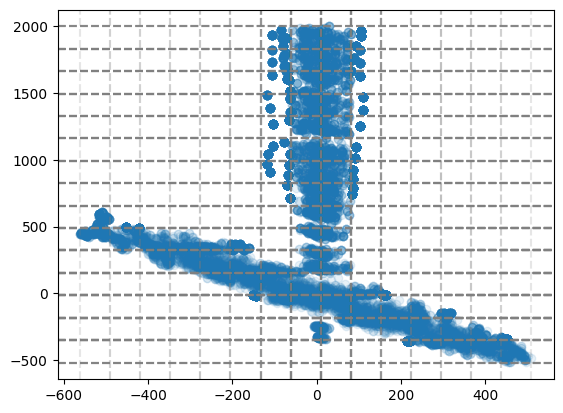

In [93]:
main = []
resd['pred_bins'] = pd.cut(resd['pred_resd'], bins=15)
resd['target_bins'] = pd.cut(resd['target_resd'], bins=15)
resd['bins'] = resd.apply(lambda x: (x['pred_bins'],x['target_bins']), axis=1)
resd.drop(columns=['pred_bins','target_bins'], inplace=True)

for bin in resd['bins'].unique():
    temp    = resd[resd['bins'] == bin]
    sampled = temp[['pred_resd', 'target_resd']].sample(n=250, replace=True).to_numpy()
    main.append(sampled)

main = np.vstack(main)   # combine all bins at the end
print(main.shape)        # (500 * n_bins, 2)
plt.scatter(main[:,0], main[:,1], alpha=0.1)
sv = [ (i[0].left.item(), i[0].right.item()) for i in resd['bins'].unique()]
sh = [ (i[1].left.item(), i[1].right.item()) for i in resd['bins'].unique()]

a = []
for i in zip(*sv):
    a += i
for i in a:
    plt.axvline(x=i, color='grey', linestyle='--', alpha=0.1)

a = []
for i in zip(*sh):
    a += i
for i in a:
    plt.axhline(y=i, color='grey', linestyle='--', alpha=0.5)


# using pca

-2.4695792135805914 0.40492728255115207


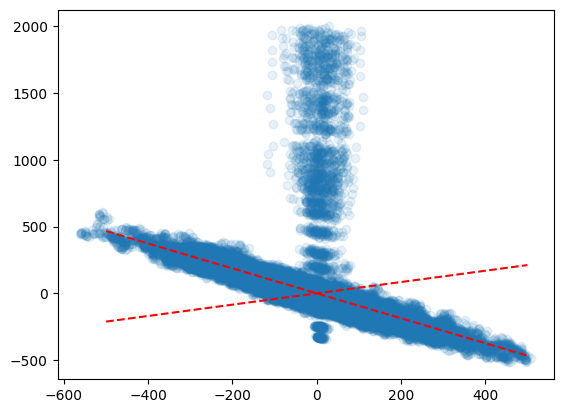

In [94]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(resd[['pred_resd','target_resd']])
# pca.fit(main)

pca.components_
components = pca.components_

xaxis = np.linspace(-500, 500, 3)

m1 = components[0][1]/components[0][0]
m2 = components[1][1]/components[1][0]

print(m1, m2)

y1 = m1*xaxis
y2 = m2*xaxis

plt.scatter(pred_resd.values, target_resd.values, alpha=0.1)

# plt.plot(xaxis, y1, 'k--')
# plt.plot(xaxis, y2, 'k--')

m3, m4 = (np.float64(-0.9315964599440725), np.float64(0.4227932187381618))

y3 = m3*xaxis
y4 = m4*xaxis
plt.plot(xaxis, y3, 'r--')
plt.plot(xaxis, y4, 'r--')

# m5, c5 = 0.052, -19.248
# m6, c6 = -0.713, -11.882
# y5 = m5*xaxis+c5
# y6 = m6*xaxis+c6
# plt.plot(xaxis, y5, 'g--')
# plt.plot(xaxis, y6, 'g--')


# houghs transform

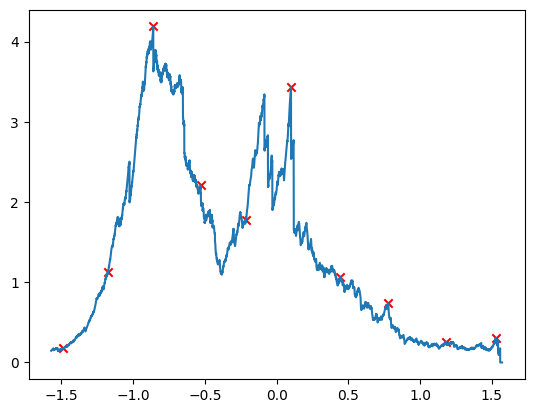

In [95]:
from scipy.signal import find_peaks

precision = 10000
error_tol = 0.05
m_ = np.linspace(np.pi/2, -np.pi/2, precision)
m = np.tan(m_)

x = np.repeat(main[:,0].reshape(-1,1), repeats=precision, axis=1)
y = main[:,1].reshape(-1,1)

mx = m*x

y_resd = np.abs(mx-y)
vote = np.where(y_resd<=error_tol, True, False).sum(axis=0)

df = pd.DataFrame({
    'x': m_,
    'y': vote
})

df['y'] = df['y'].ewm(span=precision/20).mean()

plt.plot(df['x'], df['y'])

peaks, _ = find_peaks(df['y'], distance=precision/10)

for peak in peaks:
    plt.scatter(df['x'].iloc[peak], df['y'].iloc[peak], color='red', marker='x')

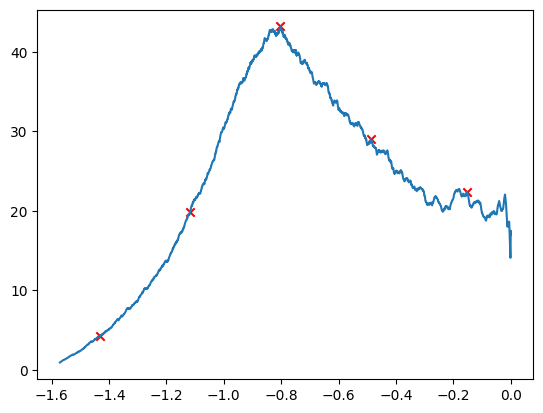

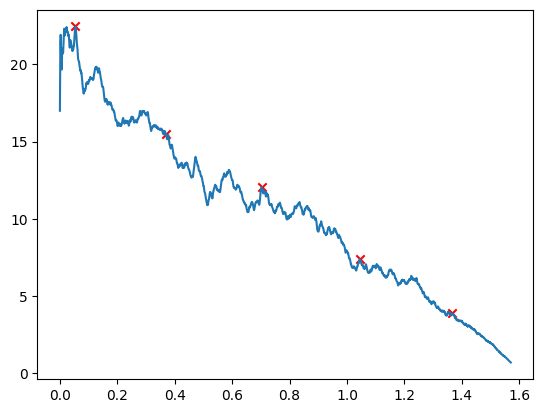

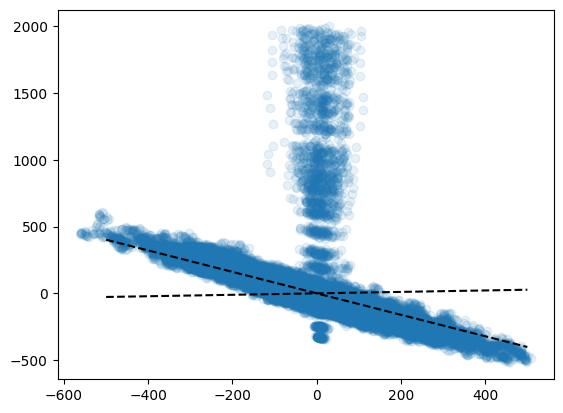

In [ ]:
from scipy.signal import find_peaks

precision = 10000
error_tol = 0.05

m_lst = []

for cor in [-1,1]:
    m_ = np.linspace(0, cor*np.pi/2, precision)
    m = np.tan(m_)
    data = resd[resd['cor']==cor]
    x = np.repeat(data['pred_resd'].to_numpy().reshape(-1,1), repeats=precision, axis=1)
    y = data['target_resd'].to_numpy().reshape(-1,1)


    mx = m*x

    y_resd = np.abs(mx-y)
    vote = np.where(y_resd<=error_tol, True, False).sum(axis=0)

    df = pd.DataFrame({
        'x': m_,
        'y': vote
    })

    df['y'] = df['y'].ewm(span=precision/20).mean()
    peaks, _ = find_peaks(df['y'], distance=precision/5)

    idx = df['y'].idxmax()
    m_lst.append(df['x'].loc[idx])

    plt.figure()
    plt.plot(df['x'], df['y'])  
    for peak in peaks:
        plt.scatter(df['x'].iloc[peak], df['y'].iloc[peak], color='red', marker='x')

xaxis = np.linspace(-500,500,3)
plt.figure()
plt.scatter(resd['pred_resd'],resd['target_resd'], alpha=0.1)
for m in m_lst:
    yaxis = m*xaxis
    plt.plot(xaxis, yaxis, 'k--')


# 